In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
import yfinance as yf

### Question 3: NVIDIA

In [ ]:
def get_nvda_data():
    """
    Stocks aren't traded every calendar day, so we keep the last 30 trading-day close prices.
    """
    df = yf.download("NVDA", period="3mo", interval="1d", auto_adjust=False, progress=False)

    if df.empty:
        raise RuntimeError("Could not download NVDA data")

    df = df.reset_index()
    df = df[["Date", "Close"]].dropna().tail(30).copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["Close"] = df["Close"].astype(float)

    return df

def train_sgd_linear_regression(x, y, epochs=5000, eta0=0.01, seed=0):
    """
    """
    rng = np.random.default_rng(seed)

    x_mean = x.mean()
    x_std = x.std()
    # Standardize x as SGD is sensitive to the scale of x
    xs = (x - x_mean) / x_std 

    # Initialize parameters
    w = 0.0 # starting slope
    b = 0.0 # starting intercept
    mse_history = [] # to record the MSE at each epoch

    for epoch in range(epochs):
        perm = rng.permutation(len(xs))  # random permutation of the data

        # As we iterate through the data, we decay the learning rate 
        eta = eta0 / (1 + 0.001 * epoch)

        for i in perm:
            y_hat = w * xs[i] + b
            err = y_hat - y[i]

            w = w - eta * err * xs[i]
            b = b - eta * err

        epoch_pred = w * xs + b
        mse = np.mean((epoch_pred - y)**2)
        mse_history.append(mse)

    # Convert back to original x scale:
    # w_std * ((x - mean)/std) + b_std = slope*x + intercept
    slope = w / x_std
    intercept = b - (w * x_mean / x_std)

    return {
        "slope": slope,
        "intercept": intercept,
        "mse_history": np.array(mse_history)
    }


#### Part a)

Last 30 trading-day NVDA close prices:


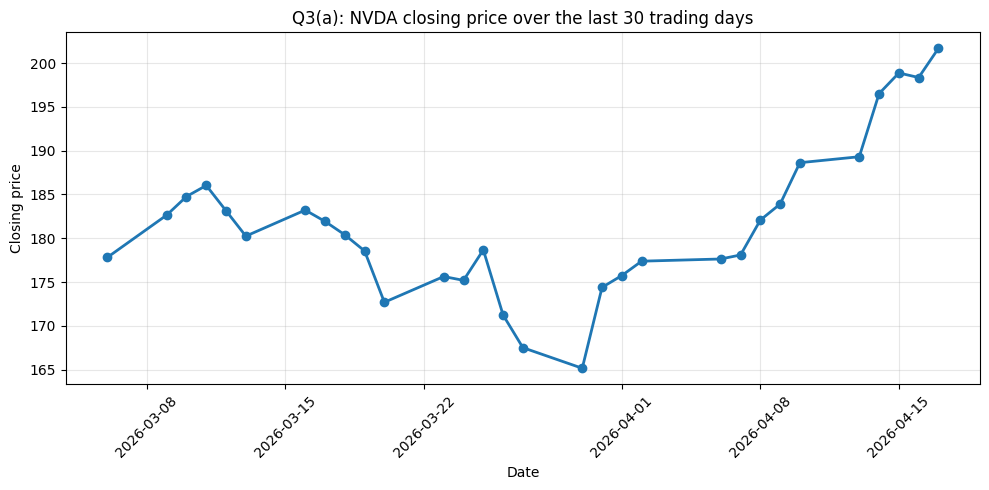

In [7]:
df = get_nvda_data()
print("Last 30 trading-day NVDA close prices:")
# print(df) 

# Part a): plot date vs stock price
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Close"], marker="o", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.title("Q3(a): NVDA closing price over the last 30 trading days")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("q3_nvda_raw_data.png", dpi=200)
plt.show()